# Notebook 09 — All Run: Pipeline Đầy Đủ Tuần 4
**Nhóm 67 | Tuần 4 | Ngôn ngữ Lập trình Python**

Notebook này chạy **toàn bộ pipeline** từ đầu đến cuối theo đúng thứ tự, gom lại từ tất cả các notebook riêng lẻ (00 → 08).

**Thứ tự thực hiện:**
1. Thiết lập môi trường & kiểm tra file
2. Đồng bộ dữ liệu (regenerate)
3. Mô phỏng 100 bài nộp sinh viên
4. EDA: Phân tích bộ dữ liệu MBPP_100
5. Kiểm thử Secure Sandbox v3
6. Chạy Baseline (kiểm chứng solution chuẩn)
7. Chấm bài tự động 100 bài nộp
8. So sánh 4 cấu hình chấm (RQ1)
9. Trực quan hóa kết quả (6 biểu đồ)
10. Khởi chạy Web Demo Streamlit


---
## PHẦN A — Thiết lập Môi trường
*Từ Notebook 00 — setup_v3*

### Kết nối Google Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')
print('✓ Kết nối Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Kết nối Drive


###  Tạo cấu trúc thư mục

In [18]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project") # Định nghĩa đường dẫn gốc

dirs = ["data/raw", "data/processed", "notebooks", "src", "results", "report"] # Tạo một danh sách các tên thư mục con cần được tạo
for d in dirs:
    (BASE / d).mkdir(parents=True, exist_ok=True) # Duyệt qua từng tên thư mục và tạo nó.
print("✅ Da tao cau truc thu muc")

requirements = """datasets
pandas
matplotlib
seaborn
"""
(BASE / "requirements.txt").write_text(requirements, encoding="utf-8") # Tạo một tệp 'requirements.txt'
print("✅ Da tao requirements.txt")

✅ Da tao cau truc thu muc
✅ Da tao requirements.txt


### Sao chép thư mục


In [19]:
from google.colab import auth
from googleapiclient.discovery import build

auth.authenticate_user()
service = build('drive', 'v3')

# ── Đổi 2 dòng này ───────────────────────────────────────────
FOLDER_ID = "1LdLseE0dpqmUWSz0tTQ0K5oiBdTBUNEE".strip()   # ID folder được chia sẻ
DEST_DIR  = "/content/drive/MyDrive/Project"  # lưu về đây
# ─────────────────────────────────────────────────────────────

import os
os.makedirs(DEST_DIR, exist_ok=True)

def copy_folder(folder_id, local_path):
    results = service.files().list(
        q=f"'{folder_id}' in parents",
        fields="files(id, name, mimeType)"
    ).execute()

    for item in results.get('files', []):
        name     = item['name']
        item_id  = item['id']
        mime     = item['mimeType']
        dst_path = os.path.join(local_path, name)

        if mime == 'application/vnd.google-apps.folder':
            # Là thư mục → đệ quy
            os.makedirs(dst_path, exist_ok=True)
            copy_folder(item_id, dst_path)
        else:
            # Là file → tải về
            content = service.files().get_media(fileId=item_id).execute()
            with open(dst_path, 'wb') as f:
                f.write(content)
            print(f"✓ {name}")

copy_folder(FOLDER_ID, DEST_DIR)
print(f"\n✓ Xong → {DEST_DIR}")

✓ 09_all_run_final.ipynb
✓ 09_all_run_final.ipynb
✓ 00_setup_v3.ipynb
✓ 06_baseline.ipynb
✓ 01_eda_v3.ipynb
✓ 05_comparison_v3.ipynb
✓ 02_runner_v3.ipynb
✓ 08_streamlit_app.ipynb
✓ 04_visualize_v3.ipynb
✓ 07_all_in_one.ipynb
✓ 03_simulate_v3.ipynb
✓ 05_comparison.ipynb
✓ 06_baseline_v3.ipynb
✓ runner.cpython-313.pyc
✓ runner.cpython-312.pyc
✓ error_stats.cpython-313.pyc
✓ generate_plots.cpython-313.pyc
✓ comparison_3sets.cpython-313.pyc
✓ regenerate_all.cpython-313.pyc
✓ simulate_v2.cpython-313.pyc
✓ run_baseline.cpython-313.pyc
✓ harden_hidden_tests.cpython-313.pyc
✓ compare_test_sets.cpython-313.pyc
✓ runner_v3.cpython-313.pyc
✓ feedback.cpython-313.pyc
✓ runner_v2.cpython-313.pyc
✓ error_stats.py
✓ runner_v3.py
✓ test_sandbox.py
✓ comparison_3sets.py
✓ diff_testing.py
✓ regenerate_all.py
✓ runner_v2.py
✓ run_baseline.py
✓ generate_plots.py
✓ run_grading_v2.py
✓ harden_hidden_tests.py
✓ feedback.py
✓ simulate_v3.py
✓ submissions_50.json
✓ mbpp_50.json
✓ submissions_50.json
✓ mbpp_cle

### Thiết lập BASE path





In [20]:
import os
import sys
import json
import subprocess
import threading
import time
from pathlib import Path

# ── Auto-detect môi trường ──────────────────────────────────────
try:
    # Colab: thư mục làm việc luôn bắt đầu bằng /content
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        from google.colab import drive  # noqa
        BASE = Path("/content/drive/MyDrive/Project")
        print("✓ Colab mode — BASE cố định tại MyDrive/Project")
    elif _cwd.name in {"report", "notebooks", "src", "data", "results"}:
        BASE = _cwd.parent
        print(f"✓ Local mode — BASE = {BASE}")
    else:
        BASE = _cwd
        print(f"✓ Local mode — BASE = {BASE}")
except Exception as e:
    BASE = Path("/content/drive/MyDrive/Project")
    print(f"⚠️ Fallback BASE: {e}")

sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)
print(f"✓ BASE     = {BASE}")
print(f"✓ src/     = {(BASE / "src").exists()}")
print(f"✓ sys.path = {sys.path[0]}")


✓ Colab mode — BASE cố định tại MyDrive/Project
✓ BASE     = /content/drive/MyDrive/Project
✓ src/     = True
✓ sys.path = /content/drive/MyDrive/Project/src


In [21]:
print(f"BASE = {BASE}")
print(f"src exists: {(BASE / 'src').exists()}")
print(f"runner_v3 exists: {(BASE / 'src' / 'runner_v3.py').exists()}")
print(f"sys.path[0] = {sys.path[0]}")

BASE = /content/drive/MyDrive/Project
src exists: True
runner_v3 exists: True
sys.path[0] = /content/drive/MyDrive/Project/src


### Cài đặt thư viện (Colab)

In [22]:
# Cài thư viện cần thiết (bỏ qua nếu đã cài)
import subprocess, sys

libs = [
    'psutil', 'pandas', 'matplotlib', 'seaborn',
    'streamlit', 'streamlit-ace', 'autopep8'
]
print('Kiểm tra & cài thư viện...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + libs, check=False)
print('✅ Thư viện đã sẵn sàng')


Kiểm tra & cài thư viện...
✅ Thư viện đã sẵn sàng


### Kiểm tra file cần thiết

In [23]:
files_to_check = {
    'runner_v3.py'       : BASE / 'src' / 'runner_v3.py',
    'hidden_v2.json'     : BASE / 'data' / 'processed' / 'hidden_v2.json',
    'submissions_50.json': BASE / 'data' / 'processed' / 'submissions_50.json',
    'feedback.py'        : BASE / 'src' / 'feedback.py',
    'comparison_3sets.py': BASE / 'src' / 'comparison_3sets.py',
    'run_grading_v2.py'  : BASE / 'src' / 'run_grading_v2.py',
    'run_baseline.py'    : BASE / 'src' / 'run_baseline.py',
    'generate_plots.py'  : BASE / 'src' / 'generate_plots.py',
    'app.py'             : BASE / 'app.py',
}
all_ok = True
for name, path in files_to_check.items():
    icon = '✓' if path.exists() else '✗ THIẾU'
    print(f'  [{icon}] {name}')
    if not path.exists(): all_ok = False

print()
if all_ok:
    print('✅ Đủ file — môi trường sẵn sàng chạy pipeline')
else:
    print('❌ Thiếu file — kiểm tra lại thư mục src/ và data/processed/')


  [✓] runner_v3.py
  [✓] hidden_v2.json
  [✓] submissions_50.json
  [✓] feedback.py
  [✓] comparison_3sets.py
  [✓] run_grading_v2.py
  [✓] run_baseline.py
  [✓] generate_plots.py
  [✓] app.py

✅ Đủ file — môi trường sẵn sàng chạy pipeline


### Kiểm tra import runner_v3

In [24]:
try:
    from runner_v3 import grade_submission, compute_leakage
    from feedback import generate_vietnamese_feedback
    print('✓ runner_v3.py import thành công')
    print('✓ feedback.py import thành công')
    print('\n✅ Môi trường sẵn sàng — tiếp tục Phần B')
except Exception as e:
    print(f'✗ Lỗi import: {e}')
    print('→ Kiểm tra lại sys.path và thư mục src/')


✓ runner_v3.py import thành công
✓ feedback.py import thành công

✅ Môi trường sẵn sàng — tiếp tục Phần B


---
## PHẦN B — Đồng bộ Dữ liệu
*Từ regenerate_all.py — tạo hidden_v2.json, mbpp_clean.json, submissions_50.json*

### B1 — Kiểm tra & chạy regenerate_all.py

In [25]:

import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"notebookes","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

hidden_file = BASE / "data" / "processed" / "hidden_v2.json"
subs_file   = BASE / "data" / "processed" / "submissions_50.json"

if hidden_file.exists() and subs_file.exists():
    print("[SKIP] Dữ liệu đã tồn tại — bỏ qua regenerate_all.py")
    print(f"  ✓ {hidden_file.name}")
    print(f"  ✓ {subs_file.name}")
    print("  → Xóa 2 file trên nếu muốn tái tạo dữ liệu từ đầu")
else:
    print("[RUN] Đang chạy regenerate_all.py...")
    import regenerate_all
    regenerate_all.main()
    print("\n✅ Đồng bộ dữ liệu hoàn tất")


[SKIP] Dữ liệu đã tồn tại — bỏ qua regenerate_all.py
  ✓ hidden_v2.json
  ✓ submissions_50.json
  → Xóa 2 file trên nếu muốn tái tạo dữ liệu từ đầu


---
## PHẦN C — Mô phỏng Bài nộp Sinh viên
*Từ Notebook 03 — simulate_v3*

### C1 — Chạy simulate_v2.generate() và kiểm tra submissions_50.json

In [26]:

import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"report","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

import simulate_v3
print("✓ Bắt đầu đồng bộ dữ liệu bài nộp sinh viên (100 bài)...")
simulate_v3.generate()


✓ Bắt đầu đồng bộ dữ liệu bài nộp sinh viên (100 bài)...
OK: Da tao 100 bai nop mo phong -> /content/drive/MyDrive/Project/data/processed/submissions_50.json
  AC: 10 bai nop
  AttributeError: 1 bai nop
  CE: 3 bai nop
  HC: 2 bai nop
  IndexError: 5 bai nop
  MLE: 2 bai nop
  NameError: 1 bai nop
  RecursionError: 1 bai nop
  TLE: 2 bai nop
  TypeError: 3 bai nop
  ValueError: 1 bai nop
  WA: 68 bai nop
  ZeroDivisionError: 1 bai nop

Summary of topic distribution:
  list: 40 bai nop
  math: 32 bai nop
  string: 28 bai nop


### C2 — Xem mẫu 3 bài nộp đầu tiên

In [27]:
import json
SUB_FILE = BASE / 'data' / 'processed' / 'submissions_50.json'
with open(SUB_FILE, encoding='utf-8') as f:
    subs = json.load(f)

print(f'✓ Đã load {len(subs)} bài nộp mô phỏng\n')

from collections import Counter
print('Phân bố error_type:')
for k, v in sorted(Counter(s['error_type'] for s in subs).items()):
    print(f'  {k:20s}: {v} bài')
print()
print('Phân bố topic:')
for k, v in sorted(Counter(s['topic'] for s in subs).items()):
    print(f'  {k:10s}: {v} bài')

print('\nMẫu 3 bài nộp đầu tiên:')
for sub in subs[:3]:
    print(f'  [{sub["submission_id"]}] Task {sub["task_id"]} | {sub["func_name"]}() | {sub["error_type"]} | {sub["note"][:60]}')


✓ Đã load 100 bài nộp mô phỏng

Phân bố error_type:
  AC                  : 10 bài
  AttributeError      : 1 bài
  CE                  : 3 bài
  HC                  : 2 bài
  IndexError          : 5 bài
  MLE                 : 2 bài
  NameError           : 1 bài
  RecursionError      : 1 bài
  TLE                 : 2 bài
  TypeError           : 3 bài
  ValueError          : 1 bài
  WA                  : 68 bài
  ZeroDivisionError   : 1 bài

Phân bố topic:
  list      : 40 bài
  math      : 32 bài
  string    : 28 bài

Mẫu 3 bài nộp đầu tiên:
  [SV001] Task 1 | sum_list() | WA | Cộng index thay vì giá trị — WA với mọi input
  [SV002] Task 1 | sum_list() | WA | Quên return — trả None
  [SV003] Task 1 | sum_list() | HC | Hard-code kết quả bài test đầu tiên


---
## PHẦN D — EDA: Phân tích Bộ dữ liệu MBPP_100
*Từ Notebook 01 — eda_v3*

### D1 — Load dữ liệu và thống kê mô tả

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = BASE / 'data' / 'processed' / 'hidden_v2.json'
with open(DATA_FILE, encoding='utf-8') as f:
    problems = json.load(f)

df = pd.DataFrame(problems)
df['num_public_tests'] = df['public_tests'].apply(len)
df['num_hidden_tests'] = df['hidden_tests'].apply(len)
df['desc_word_count']  = df['text'].apply(lambda x: len(x.split()))
df['code_line_count']  = df['code'].apply(lambda x: len(x.strip().split('\n')))

print('=============================================================')
print('  BẢNG THỐNG KÊ MÔ TẢ BỘ DỮ LIỆU MBPP_100')
print('=============================================================')
print(f'  Tổng số bài toán                   : {len(df)}')
print(f'  Phân bố chủ đề:')
for topic, count in df['topic'].value_counts().items():
    print(f'    - {topic:<15}: {count} bài')
print(f'  Public tests trung bình/bài         : {df["num_public_tests"].mean():.1f} (min={df["num_public_tests"].min()}, max={df["num_public_tests"].max()})')
print(f'  Hidden tests trung bình/bài         : {df["num_hidden_tests"].mean():.1f} (min={df["num_hidden_tests"].min()}, max={df["num_hidden_tests"].max()})')
print(f'  Độ dài mô tả trung bình (từ)        : {df["desc_word_count"].mean():.1f}')
print(f'  Độ dài code mẫu trung bình (dòng)   : {df["code_line_count"].mean():.1f}')
print('=============================================================')


  BẢNG THỐNG KÊ MÔ TẢ BỘ DỮ LIỆU MBPP_100
  Tổng số bài toán                   : 100
  Phân bố chủ đề:
    - list           : 40 bài
    - math           : 32 bài
    - string         : 28 bài
  Public tests trung bình/bài         : 3.0 (min=3, max=3)
  Hidden tests trung bình/bài         : 7.4 (min=6, max=10)
  Độ dài mô tả trung bình (từ)        : 14.5
  Độ dài code mẫu trung bình (dòng)   : 4.4


### D2 — Biểu đồ phân bố chủ đề và số hidden tests

/tmp/ipykernel_6190/643421330.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='topic', palette='viridis', ax=axes[0])


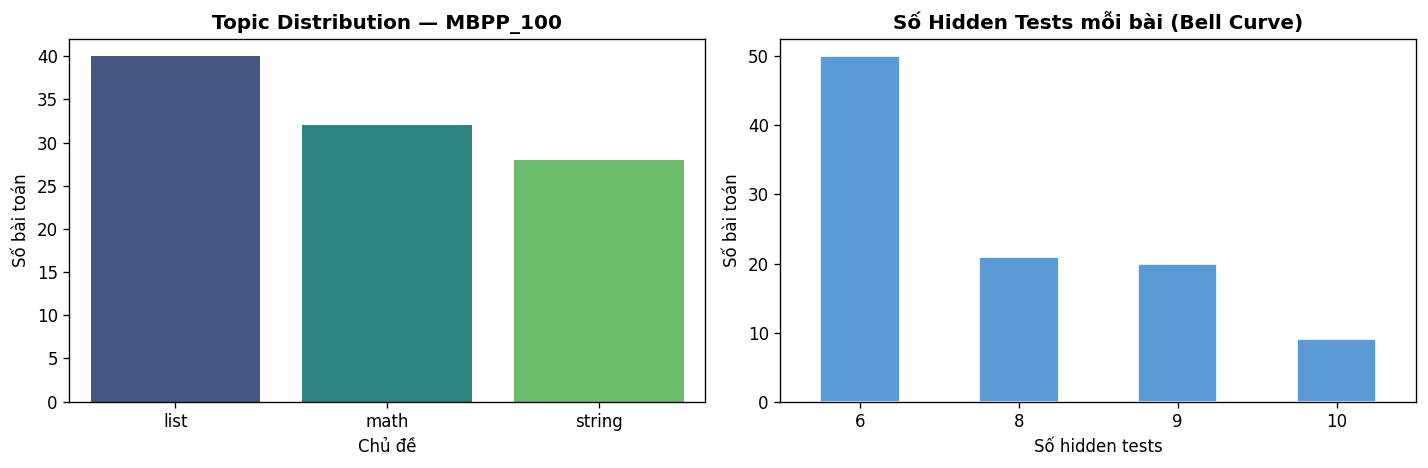

✓ Đã lưu: results/topic_distribution.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

# Plot 1: Topic distribution
sns.countplot(data=df, x='topic', palette='viridis', ax=axes[0])
axes[0].set_title('Topic Distribution — MBPP_100', fontweight='bold')
axes[0].set_xlabel('Chủ đề'); axes[0].set_ylabel('Số bài toán')

# Plot 2: Hidden test count distribution
df['num_hidden_tests'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#5B9BD5', edgecolor='white')
axes[1].set_title('Số Hidden Tests mỗi bài (Bell Curve)', fontweight='bold')
axes[1].set_xlabel('Số hidden tests'); axes[1].set_ylabel('Số bài toán')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(BASE / 'results' / 'topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Đã lưu: results/topic_distribution.png')


---
## PHẦN E — Kiểm thử Secure Sandbox v3
*Từ Notebook 02 — runner_v3 | Stress-test 13 kịch bản tấn công*

### E1 — Import Sandbox v3 và feedback module

In [30]:
# ── Đảm bảo sys.path đúng khi chạy cell độc lập ──────────────
import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"notebookes","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

from runner_v3 import grade_submission as grade_v3
from feedback import generate_vietnamese_feedback
print("✓ Import Secure Sandbox v3 thành công!")


✓ Import Secure Sandbox v3 thành công!


### E2 — Kiểm tra bộ lọc AST (import cấm, eval, dunder)

In [31]:
test_cases_ast = [
    ('import os\ndef hack(x):\n    return os.getcwd()', 'hack', 'Import cấm os'),
    ('def eval_hack(x):\n    eval("print(1)")\n    return x',   'eval_hack', 'Gọi eval()'),
    ('def dunder(x):\n    return x.__class__.__base__',           'dunder',    'Truy cập __class__'),
]
dummy_tests = [{'input': '1', 'expected': '1'}]

print('--- Kiểm tra bộ lọc AST Whitelist ---')
for code_str, func, label in test_cases_ast:
    r = grade_v3(code_str, func, dummy_tests)
    status = r['test_results'][0]['status']
    icon = '✅ CHẶN' if status == 'SE' else f'❌ BỎ SÓT [{status}]'
    print(f'  {icon} | {label}')


--- Kiểm tra bộ lọc AST Whitelist ---
  ✅ CHẶN | Import cấm os
  ✅ CHẶN | Gọi eval()
  ✅ CHẶN | Truy cập __class__


### E3 — Kiểm tra giới hạn tài nguyên (TLE & MLE)

In [32]:
test_cases_resource = [
    ('def infinite_loop(x):\n    while True:\n        pass',                             'infinite_loop', 'TLE — vòng lặp vô hạn'),
    ('def memory_leak(x):\n    y = " " * (200 * 1024 * 1024)\n    return len(y)',       'memory_leak',   'MLE — cấp phát 200MB'),
    ('def recurse(x):\n    return recurse(x + 1)',                                        'recurse',       'RecursionError — đệ quy vô hạn'),
]
dummy_tests = [{'input': '1', 'expected': '1'}]

print('--- Kiểm tra giới hạn tài nguyên ---')
for code_str, func, label in test_cases_resource:
    r = grade_v3(code_str, func, dummy_tests)
    status = r['test_results'][0]['status']
    print(f'  [{status}] {label}')


--- Kiểm tra giới hạn tài nguyên ---
  [TLE] TLE — vòng lặp vô hạn
  [MLE] MLE — cấp phát 200MB
  [RecursionError] RecursionError — đệ quy vô hạn


### E4 — Kiểm tra phản hồi sư phạm tiếng Việt

In [33]:
zero_div_code = 'def average(lst):\n    return sum(lst) / len(lst)'
tests = [{'input': '[]', 'expected': 'None'}]
r_div = grade_v3(zero_div_code, 'average', tests)
test_res = r_div['test_results'][0]

print('--- Phản hồi sư phạm tiếng Việt ---')
print(f'Lớp lỗi nhận diện : {test_res["status"]}')
print(f'Traceback gốc     :\n{test_res["error_msg"][:200]}')
print()
fb = generate_vietnamese_feedback(r_div)
print(fb)


--- Phản hồi sư phạm tiếng Việt ---
Lớp lỗi nhận diện : ZeroDivisionError
Traceback gốc     :
Traceback (most recent call last):
  File "/tmp/runner_0z21z23u/solution.py", line 7, in <module>
    result = average([])
             ^^^^^^^^^^^
  File "/tmp/runner_0z21z23u/solution.py", line 4, i

  BÁO CÁO PHẢN HỒI CHẤM BÀI TỰ ĐỘNG - HÀM: average()
  Tập test case: public          | Tỷ lệ vượt qua: 0/1 (0.0%)
  [KẾT QUẢ] Bài làm chưa hoàn thiện. Có lỗi logic hoặc lỗi runtime.

  DANH SÁCH CHI TIẾT CÁC TESTCASE BỊ LỖI:
  ------------------------------------------------------------
  1. Testcase #1: Trạng thái lỗi -> [ZeroDivisionError]
     + Input đầu vào : []
     + Kết quả mong đợi: None
     + Kết quả bài làm : N/A

     [GỢI Ý KHẮC PHỤC]:
     Lỗi Chia cho 0 (ZeroDivisionError):
  - Phép toán chia thực hiện với mẫu số bằng 0.
  - Gợi ý: Hãy kiểm tra mẫu số trước khi thực hiện chia (ví dụ: len(lst) khi lst rỗng).
  - Thêm điều kiện biên: if len(lst) == 0: return 0

     [Traceback lỗi

---
## PHẦN F — Baseline Evaluation
*Từ Notebook 06 — kiểm chứng solution chuẩn, mọi bài phải PASS 100%*

### F1 — Chạy baseline song song (ThreadPoolExecutor)

In [34]:
# ── Đảm bảo sys.path đúng khi chạy cell độc lập ──────────────
import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"report","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

import run_baseline
print("Đang chạy baseline trên toàn bộ bài toán...\n")
run_baseline.main()


Đang chạy baseline trên toàn bộ bài toán...

  CHẠY BASELINE — Code chuẩn trên 50 bài toán
  Dataset: hidden_v2.json  |  Luồng song song: 8

  ✓ Đã load 100 bài toán
  → Mỗi bài: 3 public + 6 hidden tests

  Bắt đầu chạy song song (8 luồng)...

  [✓] Task  5 count_char                     pub=3/3 hid=6/6 lat=0.3433s
  [✓] Task  6 factorial                      pub=3/3 hid=6/6 lat=0.3482s
  [✓] Task  2 is_even                        pub=3/3 hid=6/6 lat=0.3541s
  [✓] Task  8 remove_duplicates              pub=3/3 hid=6/6 lat=0.3906s
  [✓] Task  7 is_palindrome                  pub=3/3 hid=6/6 lat=0.3808s
  [✓] Task  4 find_max                       pub=3/3 hid=6/6 lat=0.3918s
  [✓] Task  1 sum_list                       pub=3/3 hid=6/6 lat=0.4096s
  [✓] Task  3 reverse_string                 pub=3/3 hid=6/6 lat=0.4231s
  [✓] Task  9 average                        pub=3/3 hid=6/6 lat=0.6168s
  [✓] Task 13 fibonacci                      pub=3/3 hid=6/6 lat=0.5713s
  [✓] Task 10 to_uppercas

### F2 — Load & kiểm tra kết quả baseline

In [35]:
df_bl = pd.read_csv(BASE / 'results' / 'baseline_summary.csv')

n_pass = df_bl['baseline_ok'].sum()
n_total = len(df_bl)
print(f'Baseline PASS: {n_pass}/{n_total} bài')
if n_pass < n_total:
    print('⚠️  Có bài FAIL — kiểm tra test case!')
    fail_cols = ['task_id', 'func_name', 'topic', 'pub_tpr', 'hid_tpr']
    display(df_bl[df_bl['baseline_ok'] == False][fail_cols])
else:
    print('✅ Tất cả bài PASS — bộ test case hợp lệ!')

print(f'\nLatency public trung bình : {df_bl["pub_latency"].mean():.4f}s/test')
print(f'Latency hidden trung bình  : {df_bl["hid_latency"].mean():.4f}s/test')
print(f'Latency tổng trung bình    : {df_bl["avg_latency_total"].mean():.4f}s/test')


Baseline PASS: 95/100 bài
⚠️  Có bài FAIL — kiểm tra test case!


,task_id,func_name,topic,pub_tpr,hid_tpr
76,77,bell_number,math,100.00,88.89
82,83,is_undulating,math,100.00,88.89
83,84,divisor,math,100.00,88.89
85,86,check_integer,math,66.67,100.00
87,88,remove_Occ,string,66.67,100.00



Latency public trung bình : 0.4691s/test
Latency hidden trung bình  : 0.5233s/test
Latency tổng trung bình    : 0.4962s/test


### F3 — Phân tích latency theo chủ đề

In [36]:
lat_by_topic = df_bl.groupby('topic')['avg_latency_total'].agg(['mean','min','max','std']).round(4)
lat_by_topic.columns = ['Trung bình (s)', 'Min (s)', 'Max (s)', 'Std (s)']
print('Latency theo chủ đề bài toán:')
display(lat_by_topic)


Latency theo chủ đề bài toán:


,Trung bình (s),Min (s),Max (s),Std (s)
topic,,,,
list,0.5259,0.3906,0.7406,0.0995
math,0.4990,0.3482,0.6733,0.1116
string,0.4506,0.2243,0.7500,0.1430


---
## PHẦN G — Chấm Bài Tự Động 100 Bài Nộp
*Từ run_grading_v2.py — dùng runner_v3, sinh error_analysis_v2.csv*

### G1 — Chạy chấm bài (runner_v3, 3 public + 6-10 hidden)

In [37]:
# ── Đảm bảo sys.path đúng khi chạy cell độc lập ──────────────
import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"report","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

import run_grading_v2
print("Đang chấm 100 bài nộp mô phỏng...\n")
run_grading_v2.main()


Đang chấm 100 bài nộp mô phỏng...

  CHẠY CHẤM BÀI TỰ ĐỘNG V2
  Bộ test: 3 public + 6-10 hidden (Phân bố Chuông)

  ✓ Đã load 100 bài nộp mô phỏng
  ✓ Đã load 100 bài toán MBPP
  ✓ Số bài sẽ chấm: 100/100

  Bắt đầu chấm (sử dụng psutil giới hạn tài nguyên và thu thập lỗi)...

  Chấm xong 10/100 bài...
  Chấm xong 20/100 bài...
  Chấm xong 30/100 bài...
  Chấm xong 40/100 bài...
  Chấm xong 50/100 bài...
  Chấm xong 60/100 bài...
  Chấm xong 70/100 bài...
  Chấm xong 80/100 bài...
  Chấm xong 90/100 bài...
  Chấm xong 100/100 bài...
  ✓ Lưu CSV: /content/drive/MyDrive/Project/results/error_analysis_v2.csv
  ✓ Lưu JSON (Đầy đủ traceback): /content/drive/MyDrive/Project/results/error_analysis_v2.json

  KẾT QUẢ CHẤM BÀI V2 (Set 3: Bell Curve)
  Tổng submissions        : 100
  Public Test Leakage Rate: 17.0% (17 bài)
  Avg TPR public (3 test) : 36.33%
  Avg TPR hidden (10 test): 39.71%
  Latency public          : 0.0696s/test
  Latency hidden          : 0.0706s/test

  Lỗi PUBLIC  → SE:9 

### G2 — Tổng hợp kết quả chấm bài

In [38]:
df_grading = pd.read_csv(BASE / 'results' / 'error_analysis_v2.csv')
print(f'Tổng bài chấm: {len(df_grading)}')
print(f'\nPhân bố trạng thái chấm bài:')
if 'is_false_positive' in df_grading.columns:
    fp = df_grading['is_false_positive'].sum()
    print(f'  False Positive (pub=100%, hid<100%): {fp} bài ({fp/len(df_grading)*100:.1f}%)')
print(f'\nLatency trung bình (hidden) : {df_grading["avg_latency_hid"].mean():.4f}s/test')
print(f'Latency trung bình (public) : {df_grading["avg_latency_pub"].mean():.4f}s/test')
display(df_grading[['sv_id','task_id','func','topic','pub_tpr','hid_tpr','is_false_positive']].head(10))


Tổng bài chấm: 100

Phân bố trạng thái chấm bài:
  False Positive (pub=100%, hid<100%): 17 bài (17.0%)

Latency trung bình (hidden) : 0.0706s/test
Latency trung bình (public) : 0.0696s/test


,sv_id,task_id,func,topic,pub_tpr,hid_tpr,is_false_positive
0,SV001,1,sum_list,list,0.00,33.33,False
1,SV002,1,sum_list,list,0.00,0.00,False
2,SV003,1,sum_list,list,100.00,83.33,True
3,SV004,2,is_even,math,0.00,0.00,False
4,SV005,2,is_even,math,66.67,50.00,False
5,SV006,3,reverse_string,string,0.00,33.33,False
6,SV007,4,find_max,list,0.00,33.33,False
7,SV008,4,find_max,list,100.00,83.33,True
8,SV009,6,factorial,math,100.00,100.00,False
9,SV010,6,factorial,math,66.67,33.33,False


---
## PHẦN H — So sánh 4 Cấu hình Chấm bài (RQ1)
*Từ Notebook 05 — comparison_v3 | Sinh comparison_week4.csv*

### H1 — Chạy comparison_3sets.main() (4 Set)

In [39]:
# ── Đảm bảo sys.path đúng khi chạy cell độc lập ──────────────
import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"report","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

import comparison_3sets
print("Đang chạy so sánh 4 cấu hình kiểm thử...\n")
comparison_3sets.main()


Đang chạy so sánh 4 cấu hình kiểm thử...

  HE THONG graded VA SO SANH CAC BO TEST CASES (WEEK 4 EVALUATION)
  [OK] Da load 100 bai nop mo phong.
  [OK] Da load bo test hidden v2 (Set 3/4): 100 bai.
  [OK] Da load bo test 6 hidden (Set 2): 100 bai.

  Bat dau cham bai tren 4 cau hinh test cases...

  So submissions AC (dung): 10
  So submissions Buggy (Faulty): 90
--------------------------------------------------------------------------------
  [SV001] sum_list             | Act: WA   | S1: 0/3 | S3: 2/9 | S4 (FF): 0/9 
  [SV002] sum_list             | Act: WA   | S1: 0/3 | S3: 0/9 | S4 (FF): 0/9 
  [SV003] sum_list             | Act: HC   | S1: 3/3 | S3: 8/9 | S4 (FF): 6/9 [FP S1]
  [SV004] is_even              | Act: CE   | S1: 0/3 | S3: 0/9 | S4 (FF): 0/9 
  [SV005] is_even              | Act: WA   | S1: 2/3 | S3: 5/9 | S4 (FF): 1/9 
  [SV006] reverse_string       | Act: WA   | S1: 0/3 | S3: 2/9 | S4 (FF): 0/9 
  [SV007] find_max             | Act: IndexError | S1: 0/3 | S3: 2/9 | 

### H2 — Hiển thị bảng kết quả comparison_week4.csv

In [40]:
df_comp = pd.read_csv(BASE / 'results' / 'comparison_week4.csv')
print(f'Tổng: {len(df_comp)} bài nộp được so sánh')
print(f'Columns: {list(df_comp.columns)[:8]}...')

cols_show = [c for c in ['sv_id','task_id','func','topic','actual_error_type',
                           'set1_tpr','set2_tpr','set3_tpr','set4_tpr',
                           'is_fp_set1','is_fp_set2','is_fp_set3','is_fp_set4'] if c in df_comp.columns]
display(df_comp[cols_show].head(10))


Tổng: 100 bài nộp được so sánh
Columns: ['sv_id', 'task_id', 'func', 'topic', 'mo_ta_loi', 'actual_error_type', 'set1_pass', 'set1_total']...


,sv_id,task_id,func,topic,actual_error_type,set1_tpr,set2_tpr,set3_tpr,set4_tpr,is_fp_set1,is_fp_set2,is_fp_set3,is_fp_set4
0,SV001,1,sum_list,list,WA,0.00,22.22,22.22,0.00,False,False,False,False
1,SV002,1,sum_list,list,WA,0.00,0.00,0.00,0.00,False,False,False,False
2,SV003,1,sum_list,list,HC,100.00,88.89,88.89,66.67,True,False,False,False
3,SV004,2,is_even,math,CE,0.00,0.00,0.00,0.00,False,False,False,False
4,SV005,2,is_even,math,WA,66.67,55.56,55.56,11.11,False,False,False,False
5,SV006,3,reverse_string,string,WA,0.00,22.22,22.22,0.00,False,False,False,False
6,SV007,4,find_max,list,IndexError,0.00,22.22,22.22,0.00,False,False,False,False
7,SV008,4,find_max,list,IndexError,100.00,88.89,88.89,33.33,True,False,False,False
8,SV009,6,factorial,math,AC,100.00,100.00,100.00,100.00,False,False,False,False
9,SV010,6,factorial,math,HC,66.67,44.44,44.44,0.00,False,False,False,False


---
## PHẦN I — Trực quan hóa Kết quả (6 Biểu đồ)
*Từ Notebook 04 — visualize_v3 | Đọc từ comparison_week4.csv*

### I1 — Kiểm tra file đầu vào và chạy generate_plots.main()

In [41]:
# ── Đảm bảo sys.path đúng khi chạy cell độc lập ──────────────
import os, sys
from pathlib import Path
try:
    _cwd = Path.cwd()
    if str(_cwd).startswith("/content"):
        BASE = Path("/content/drive/MyDrive/Project")
    elif _cwd.name in {"report","notebooks","src","data","results"}:
        BASE = _cwd.parent
    else:
        BASE = _cwd
except Exception:
    BASE = Path("/content/drive/MyDrive/Project")
if str(BASE / "src") not in sys.path:
    sys.path.insert(0, str(BASE / "src"))
os.chdir(BASE)

import generate_plots

csv_file = BASE / "results" / "comparison_week4.csv"
if not csv_file.exists():
    print(f"[LỖI] Chưa có comparison_week4.csv — hãy chạy Phần H trước!")
else:
    print(f"[OK] Tìm thấy comparison_week4.csv — bắt đầu vẽ biểu đồ...")
    generate_plots.main()


[OK] Tìm thấy comparison_week4.csv — bắt đầu vẽ biểu đồ...
  BAT DAU VE CAC BIEU DO TRUC QUAN HOA KET QUA WEEK 4
  [OK] Du lieu tai thanh cong: 100 hang.
  [OK] Da ve va luu: /content/drive/MyDrive/Project/results/FPR_vs_ntest.png
  [OK] Da ve va luu: /content/drive/MyDrive/Project/results/error_types_comparison.png
  [OK] Da ve va luu: /content/drive/MyDrive/Project/results/fpr_by_topic.png
  [OK] Da ve va luu bieu do latency: /content/drive/MyDrive/Project/results/latency_comparison.png
  [OK] Da ve va luu bieu do mo ta ghep: /content/drive/MyDrive/Project/results/description_lengths_distribution.png
  [OK] Da ve va luu bieu do so sanh rieng: /content/drive/MyDrive/Project/results/full_vs_failfast_latency.png

  [OK] Hoan tat! Tat ca bieu do da duoc luu trong: /content/drive/MyDrive/Project/results


### I2 — Hiển thị toàn bộ 6 biểu đồ kết quả


1. Đường cong FPR theo số test case (RQ1):


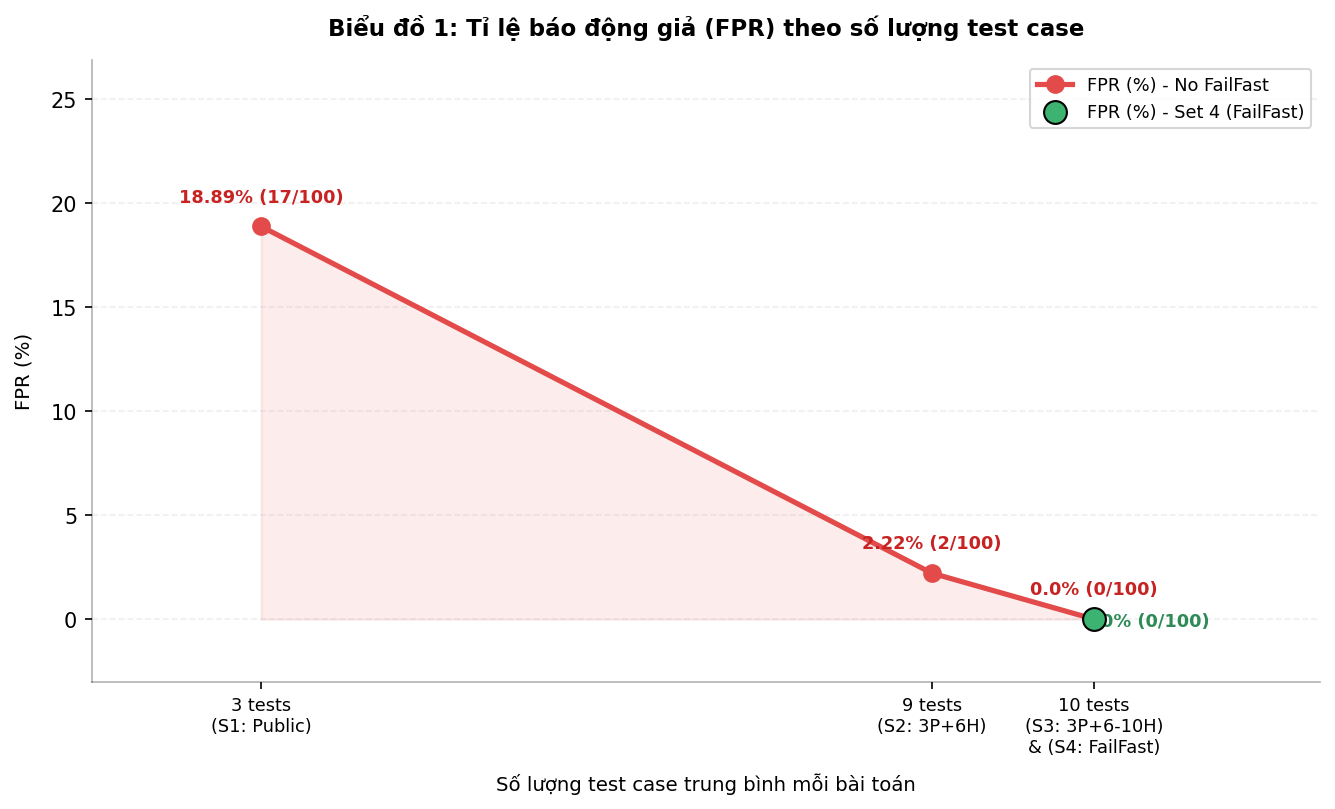


2. Phân bố lỗi SE/WA/RE/TLE/MLE (4 bộ test):


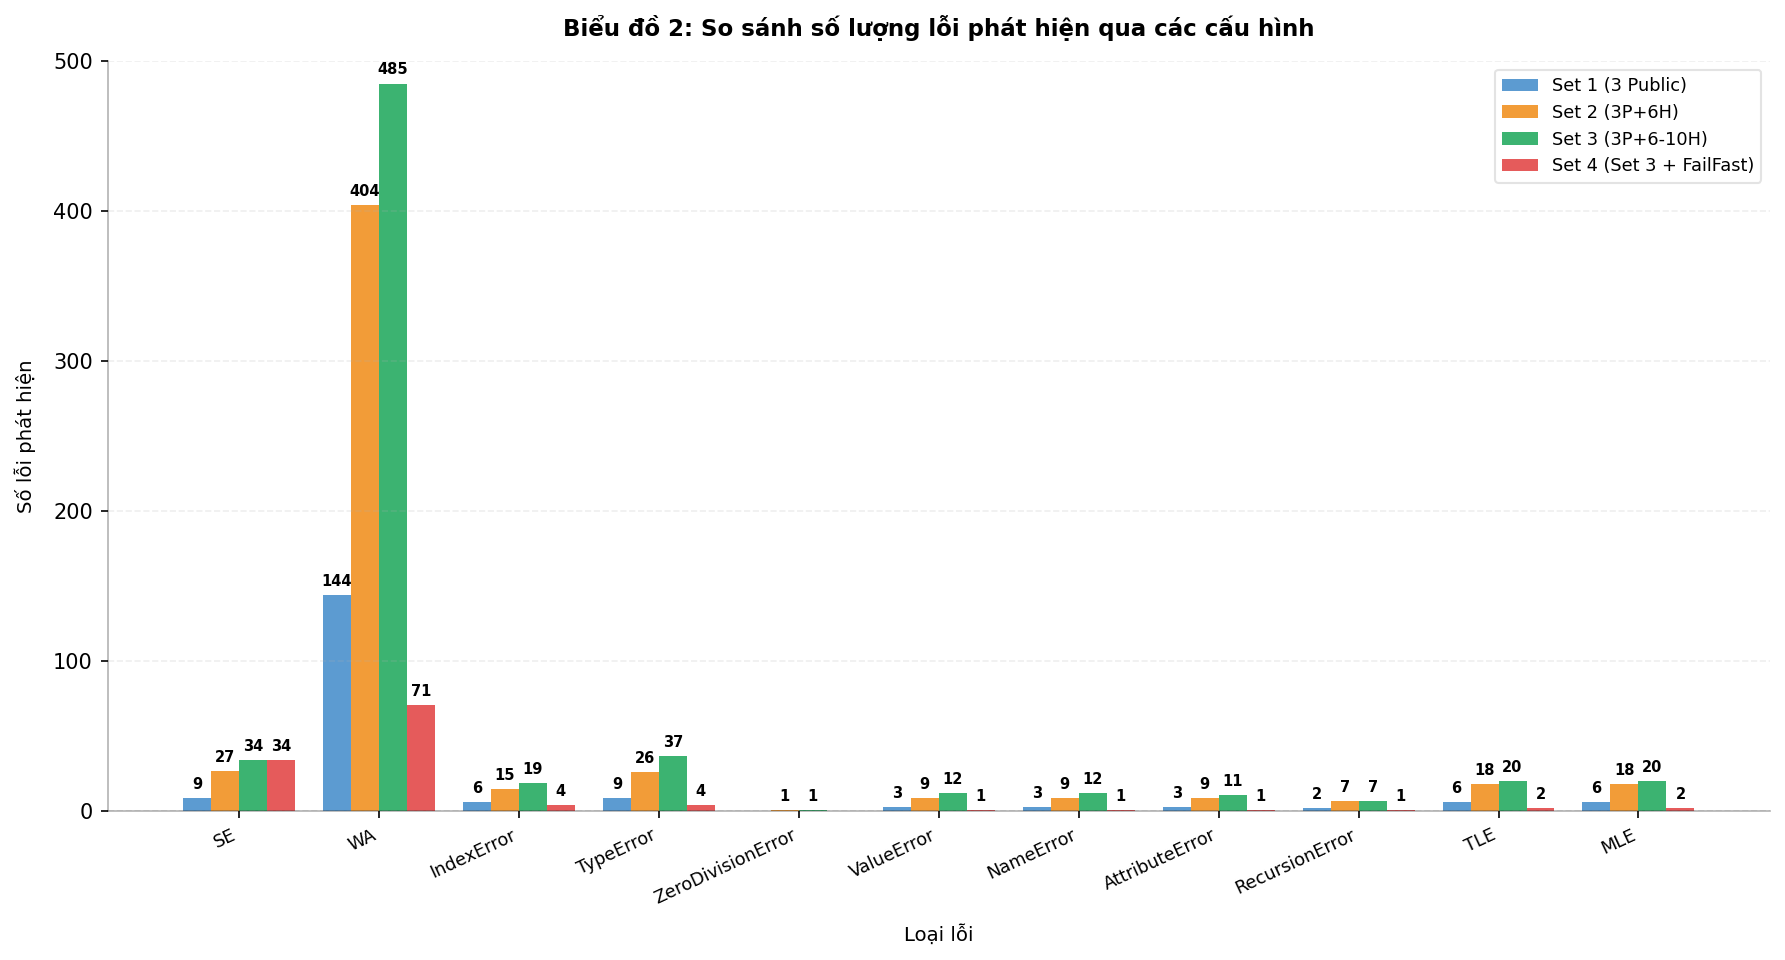


3. FPR theo chủ đề bài toán:


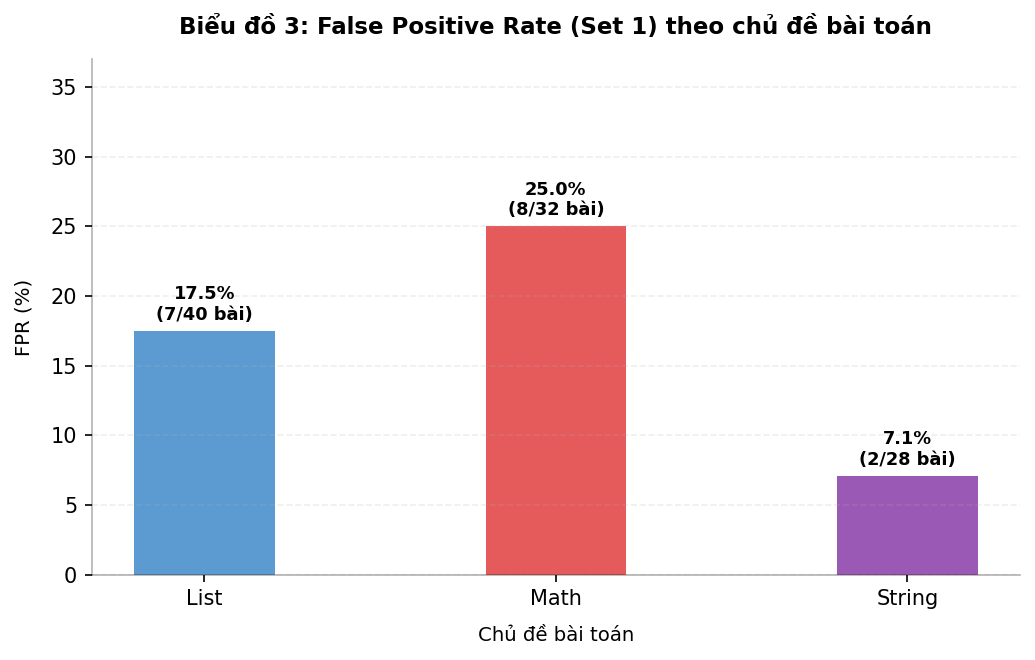


4. So sánh Latency (4 Set):


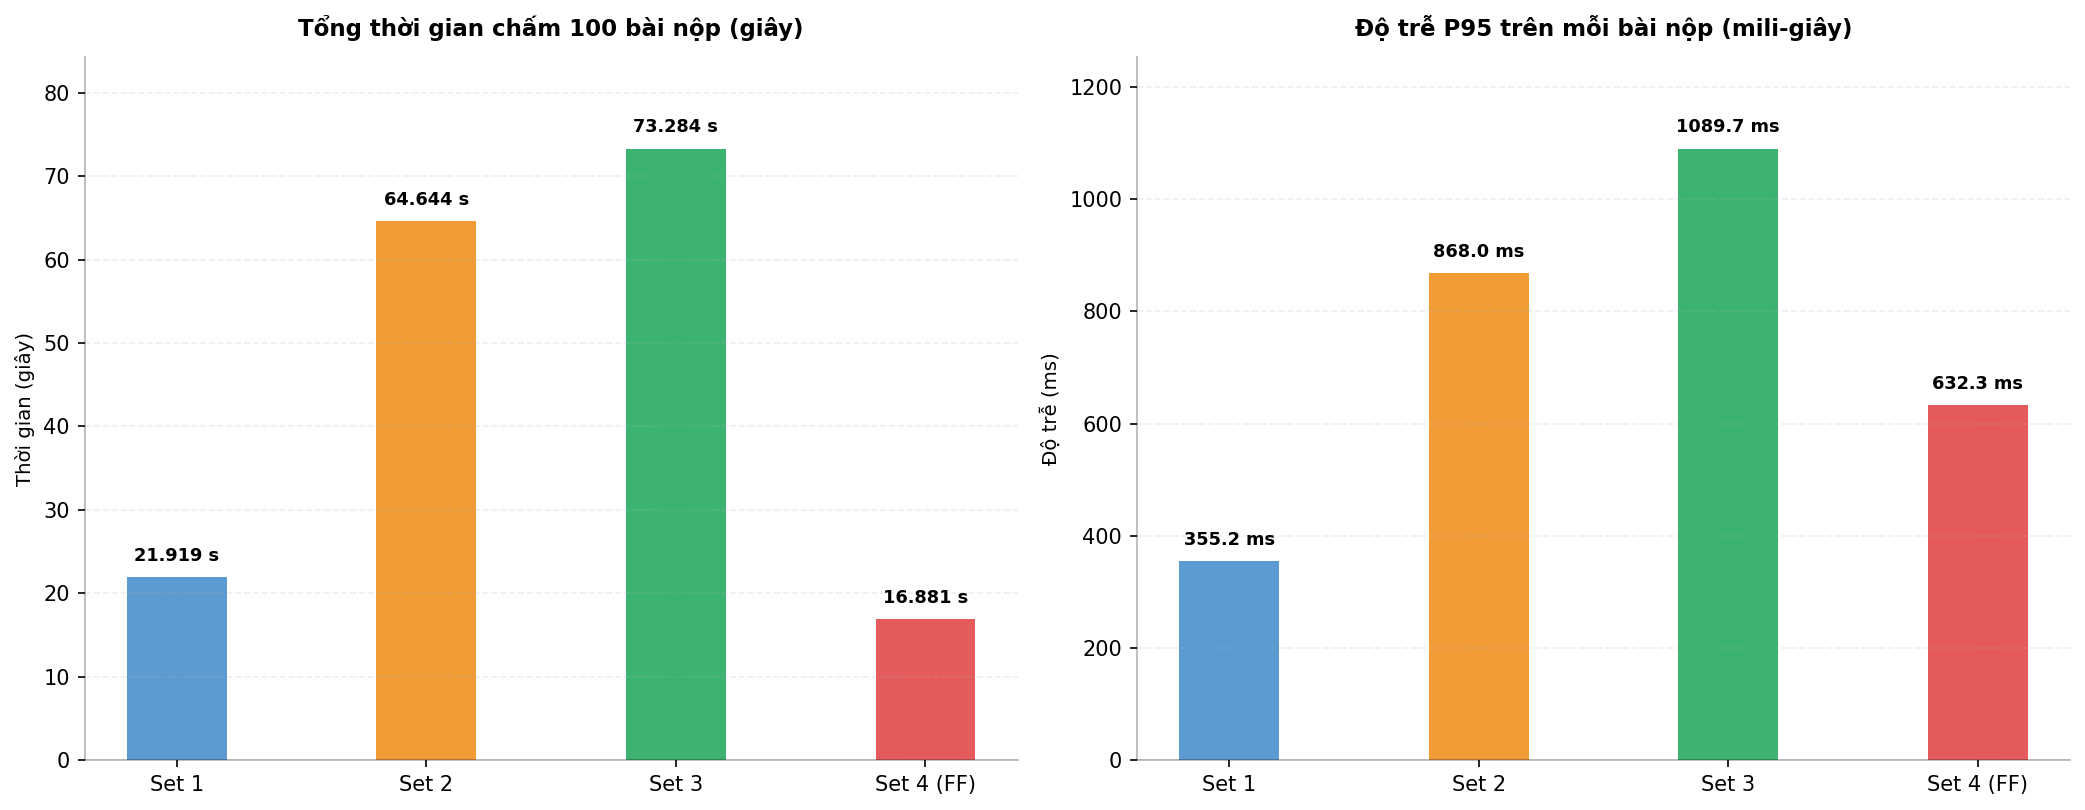


5. Full-run vs Fail-Fast Latency:


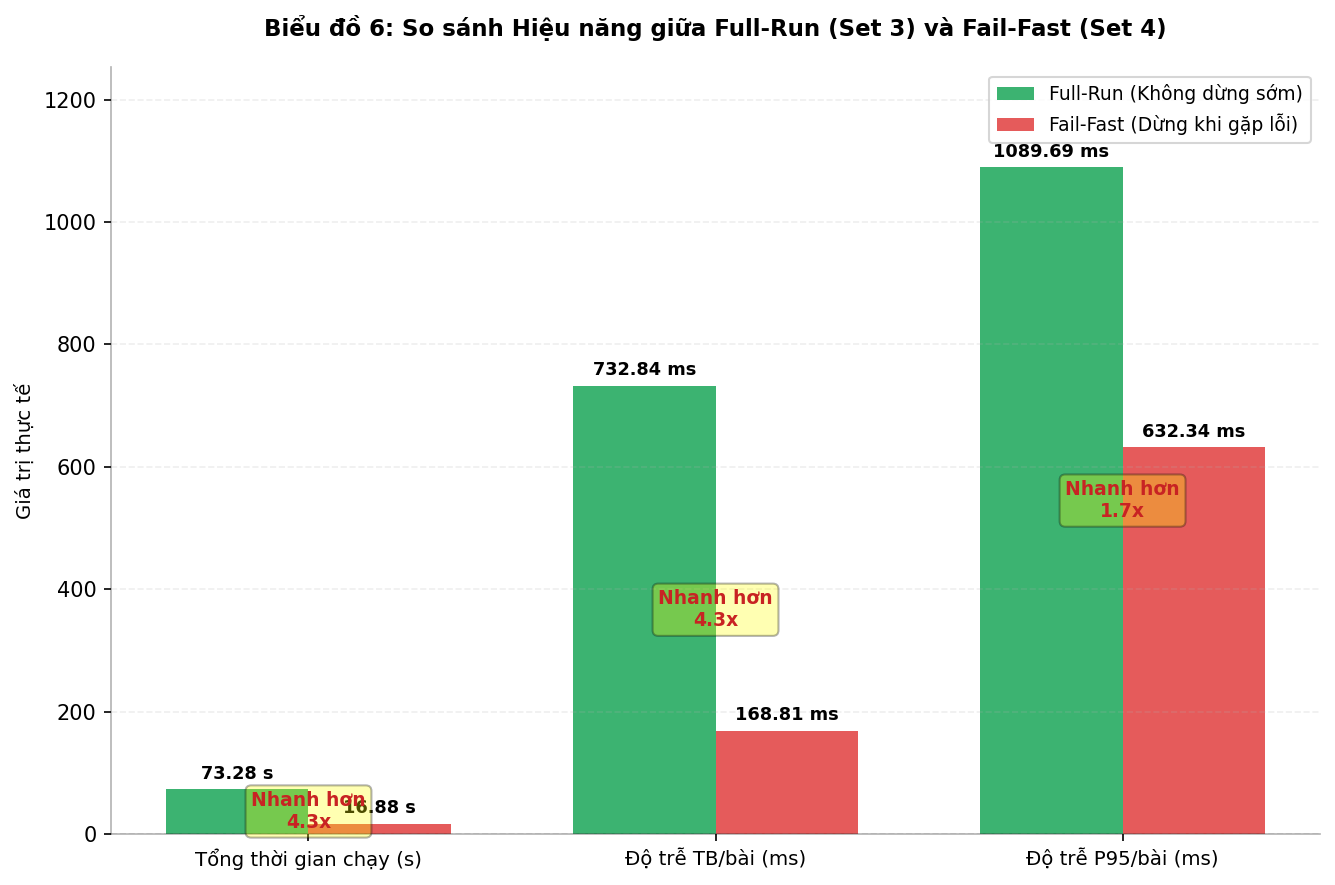


6. Phân bố độ dài mô tả & số test/bài:


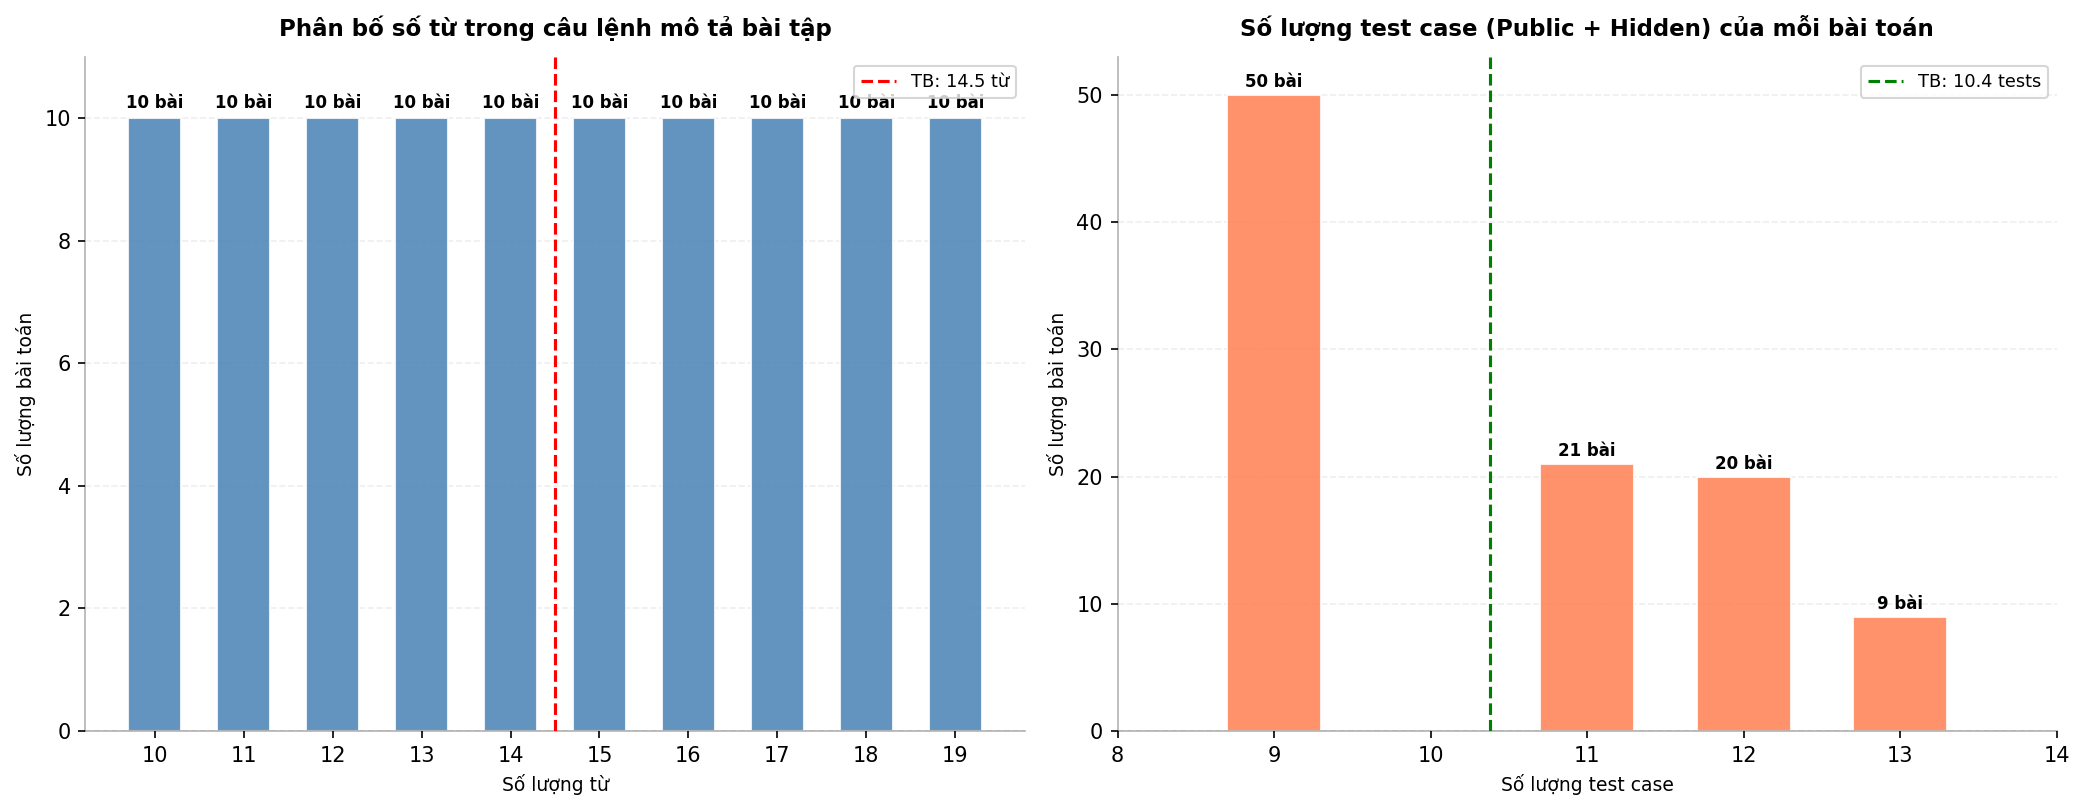

In [42]:
from IPython.display import Image, display as ipy_display

plots = [
    ('1. Đường cong FPR theo số test case (RQ1)',    'FPR_vs_ntest.png'),
    ('2. Phân bố lỗi SE/WA/RE/TLE/MLE (4 bộ test)', 'error_types_comparison.png'),
    ('3. FPR theo chủ đề bài toán',                  'fpr_by_topic.png'),
    ('4. So sánh Latency (4 Set)',                    'latency_comparison.png'),
    ('5. Full-run vs Fail-Fast Latency',              'full_vs_failfast_latency.png'),
    ('6. Phân bố độ dài mô tả & số test/bài',        'description_lengths_distribution.png'),
]

for title, fname in plots:
    fpath = BASE / 'results' / fname
    if fpath.exists():
        print(f'\n{title}:')
        ipy_display(Image(filename=str(fpath)))
    else:
        print(f'[THIẾU] {fname} — chưa được tạo')


---
## PHẦN J — Khởi chạy Web Demo Streamlit
*Từ Notebook 08 — streamlit_app | URL: http://localhost:8501*

### J1 — Kiểm tra app.py và khởi động Streamlit

In [43]:
app_path = BASE / 'app.py'
print(f'✓ BASE = {BASE}')
print(f'✓ app.py exists: {app_path.exists()}')
if not app_path.exists():
    raise FileNotFoundError(f'Không tìm thấy {app_path}')

# ── Local: chạy trực tiếp ──────────────────────────────────────
# Bỏ comment 3 dòng dưới nếu chạy trên Local Machine:
# streamlit_proc = subprocess.Popen(
#     [sys.executable, '-m', 'streamlit', 'run', str(app_path), '--server.port', '8501'],
#     cwd=str(BASE))
# print(f'Streamlit PID: {streamlit_proc.pid} | URL: http://localhost:8501')

# ── Colab: dùng pyngrok ────────────────────────────────────────
try:
    from pyngrok import ngrok
    def _run_st():
        subprocess.run([sys.executable, '-m', 'streamlit', 'run', str(app_path),
                        '--server.port', '8501', '--server.headless', 'true'], cwd=str(BASE))
    threading.Thread(target=_run_st, daemon=True).start()
    time.sleep(6)
    public_url = ngrok.connect(8501)
    print(f'✅ Web Demo đang chạy tại: {public_url}')
    print('   (Colab mode — dùng pyngrok)')
except ImportError:
    print('pyngrok chưa được cài — chạy: !pip install pyngrok')
    print('Hoặc bỏ comment phần Local ở trên nếu chạy trên máy cá nhân')


✓ BASE = /content/drive/MyDrive/Project
✓ app.py exists: True
pyngrok chưa được cài — chạy: !pip install pyngrok
Hoặc bỏ comment phần Local ở trên nếu chạy trên máy cá nhân


### J2 — Dừng Streamlit (chạy khi không cần nữa)

In [44]:
# Dừng ngrok tunnel (Colab)
try:
    from pyngrok import ngrok as _ngrok
    _ngrok.kill()
    print('✓ Đã dừng ngrok tunnel')
except Exception:
    pass

# Dừng process (Local)
if 'streamlit_proc' in globals() and streamlit_proc.poll() is None:
    streamlit_proc.terminate()
    streamlit_proc.wait(timeout=10)
    print('✓ Đã dừng Streamlit')
else:
    print('Streamlit chưa chạy hoặc đã dừng')


Streamlit chưa chạy hoặc đã dừng


---
## PHẦN K — Tổng kết Pipeline

### K1 — Kiểm tra toàn bộ file kết quả đầu ra

In [45]:
print('=' * 60)
print('  TỔNG KẾT FILE KẾT QUẢ ĐẦU RA')
print('=' * 60)

output_files = {
    'Baseline'          : BASE / 'results' / 'baseline_summary.csv',
    'Baseline JSON'     : BASE / 'results' / 'baseline_summary.json',
    'Grading CSV'       : BASE / 'results' / 'error_analysis_v2.csv',
    'Grading JSON'      : BASE / 'results' / 'error_analysis_v2.json',
    'Comparison CSV'    : BASE / 'results' / 'comparison_week4.csv',
    'Comparison JSON'   : BASE / 'results' / 'comparison_week4.json',
    'FPR chart'         : BASE / 'results' / 'FPR_vs_ntest.png',
    'Error chart'       : BASE / 'results' / 'error_types_comparison.png',
    'FPR by topic'      : BASE / 'results' / 'fpr_by_topic.png',
    'Latency chart'     : BASE / 'results' / 'latency_comparison.png',
    'Fail-fast chart'   : BASE / 'results' / 'full_vs_failfast_latency.png',
    'Desc lengths chart': BASE / 'results' / 'description_lengths_distribution.png',
    'Topic chart'       : BASE / 'results' / 'topic_distribution.png',
}

n_ok = 0
for name, path in output_files.items():
    icon = '✓' if path.exists() else '✗ THIẾU'
    size = f'{path.stat().st_size/1024:.1f} KB' if path.exists() else ''
    print(f'  [{icon}] {name:<22} {size}')
    if path.exists(): n_ok += 1

print()
print(f'  Kết quả: {n_ok}/{len(output_files)} file đã được tạo')
if n_ok == len(output_files):
    print('  ✅ Pipeline hoàn chỉnh!')
else:
    print('  ⚠️  Còn thiếu file — kiểm tra lại các bước bị lỗi ở trên')
print('=' * 60)


  TỔNG KẾT FILE KẾT QUẢ ĐẦU RA
  [✓] Baseline               9.8 KB
  [✓] Baseline JSON          58.4 KB
  [✓] Grading CSV            14.9 KB
  [✓] Grading JSON           246.9 KB
  [✓] Comparison CSV         17.4 KB
  [✓] Comparison JSON        72.7 KB
  [✓] FPR chart              79.8 KB
  [✓] Error chart            87.7 KB
  [✓] FPR by topic           42.0 KB
  [✓] Latency chart          71.2 KB
  [✓] Fail-fast chart        77.9 KB
  [✓] Desc lengths chart     68.0 KB
  [✓] Topic chart            42.6 KB

  Kết quả: 13/13 file đã được tạo
  ✅ Pipeline hoàn chỉnh!
